## https://github.com/2Myaka2/DataScience_projects

### работал в репозитории

# Поведенческий скоринг клиентов банка: прогноз риска просрочки 90+ дней

## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.

## Подготовка рабочего пространства

### Постановка задачи

В рамках проекта решается задача поведенческого скоринга клиентов банка. Необходимо построить модель, которая по данным о клиенте на конкретную дату скоринга будет прогнозировать вероятность возникновения просрочки платежа по кредиту длительностью 90 дней и более.

Объектом моделирования является не клиент в целом, а пара «клиент — месяц наблюдения». Для каждого клиента в каждый месяц необходимо определить, возникнет ли у него просрочка 90+ дней в течение следующих 12 месяцев. Если такая просрочка возникает, целевая переменная принимает значение `1`, если не возникает — `0`.

Практический смысл задачи состоит в том, чтобы заранее выявлять клиентов с повышенным риском дефолта. Это позволит банку точнее управлять кредитным риском, резервами и ликвидностью: не пропускать действительно рискованных клиентов, но при этом не относить к зоне риска слишком большую долю надёжных клиентов.

### Описание данных

Для решения задачи предоставлены несколько таблиц с данными о клиентах, кредитах, транзакциях, просрочках и макроэкономических условиях.

| Таблица | Содержание |
|---|---|
| `ds_15_cohort_grid.csv` | Даты проведения поведенческого скоринга. Содержит идентификатор клиента `ID` и дату скоринга `score_date`. Эта таблица задаёт базовую сетку наблюдений «клиент — месяц». |
| `ds_15_loan_payment_credit.csv` | Данные о просрочках платежей: идентификатор клиента, дата начала периода просрочки и количество дней просрочки. На основе этой таблицы будет формироваться целевая переменная. |
| `ds_15_transactions.csv` | Помесячные транзакции клиента по MCC-кодам: траты в маркетплейсах, фастфуде, ресторанах, супермаркетах, сервисах Яндекса, магазинах бытовой техники, ЖКУ и прочих категориях. |
| `ds_15_client_description.csv` | Социально-демографическое описание клиента на момент регистрации в банке: возраст, семейное положение, наличие иждивенцев, дата регистрации. |
| `ds_15_credit_description.csv` | Описание кредита: месячный доход клиента и сумма выданного кредита. |
| `ds_15_mortgage_presence.csv` | Информация о наличии ипотеки: дата открытия ипотеки и признак наличия ипотеки. |
| `ds_15_credit_rating.csv` | Динамика кредитного рейтинга клиента по датам. |
| `ds_15_macro_data.csv` | Макроэкономические показатели по месяцам: учётная ставка, уровень безработицы и инфляция. |

Перед моделированием все источники данных будут объединены в единую таблицу наблюдений. При объединении будет важно учитывать временную структуру данных: в признаках для каждой строки должны использоваться только те данные, которые были доступны на дату скоринга.

## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


## Перевод бизнес-задачи на язык машинного обучения

С точки зрения машинного обучения задача является задачей бинарной классификации.

Для каждой строки итоговой таблицы, соответствующей клиенту в конкретный месяц, необходимо предсказать целевую переменную:

- `1` — в течение следующих 12 месяцев у клиента возникнет просрочка платежа длительностью 90 дней и более;
- `0` — в течение следующих 12 месяцев такой просрочки не возникнет.

В качестве признаков будут использоваться социально-демографические характеристики клиента, параметры кредита, история транзакций, сведения об ипотеке, динамика кредитного рейтинга, информация о текущих и прошлых просрочках, а также макроэкономические показатели.

### План решения

Сначала будет проведена загрузка и первичный анализ всех таблиц: проверка типов данных, пропусков, дубликатов, выбросов и временных диапазонов. После этого будет сформирована единая таблица наблюдений на основе `cohort_grid`, где каждая строка соответствует паре «клиент — дата скоринга».

Особое внимание будет уделено корректному формированию целевой переменной. Для каждой даты скоринга будет проверяться, возникла ли у клиента просрочка 90+ дней в течение следующих 12 месяцев. При этом признаки должны строиться только на основе информации, доступной на момент скоринга, чтобы избежать утечки данных из будущего.

Для повышения качества модели будут созданы дополнительные признаки, например:

- отношение суммы кредита к доходу клиента;
- срок жизни клиента в банке на дату скоринга;
- агрегированные признаки по транзакциям;
- признаки динамики кредитного рейтинга;
- признаки, связанные с наличием ипотеки и семейной нагрузкой.

После подготовки данных будет проанализирован баланс классов в целевой переменной. Так как дефолты обычно встречаются существенно реже, чем нормальные платежи, задача, вероятно, будет несбалансированной. Поэтому будут рассмотрены методы балансировки классов: `class_weight`, `RandomOverSampler`, `RandomUnderSampler` или `SMOTE`.

### Модели

На базовом этапе будут обучены и сравнены несколько вариантов моделей:

1. логистическая регрессия без балансировки классов;
2. случайный лес без балансировки классов;
3. логистическая регрессия с балансировкой классов;
4. случайный лес с балансировкой классов.

Для итогового решения будет использована ансамблевая модель `RandomForestClassifier`, так как она способна учитывать нелинейные зависимости между признаками, работает с признаками разного масштаба и позволяет оценить важность признаков через `feature_importances_`.

Подбор гиперпараметров итоговой модели будет выполнен с помощью `Optuna`. Для валидации будет использоваться кросс-валидация на трёх фолдах с учётом временной структуры данных и группировки по клиентам через `GroupTimeSeriesSplit`.

### Оценка качества

Качество моделей будет оцениваться как техническими, так и бизнес-метриками.

В качестве технической метрики для сравнения моделей будет использоваться ROC-AUC или accuracy. Однако основное внимание будет уделено бизнес-метрикам:

- `approval rate` — доля клиентов, которых модель считает надёжными;
- `default rate` — доля фактических дефолтов среди клиентов, признанных моделью надёжными;
- `missed defaults rate` — доля дефолтов, которые модель пропустила.

После обучения лучшей модели будет проведена калибровка вероятностей на отдельной калибровочной выборке. Затем будет подобран порог классификации, при котором одновременно выполняются бизнес-ограничения:

- `approval rate` не менее 65%;
- `default rate` не более 2%;
- `missed defaults rate` не более 4%.

Финальная проверка качества будет выполнена на тестовой выборке, которая не будет использоваться ни при обучении модели, ни при подборе гиперпараметров, ни при калибровке, ни при выборе порога. Это позволит оценить, насколько стабильно модель работает на новых данных.

## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [10]:
%%writefile requirements.txt
numpy==1.26.4
pandas==2.2.3
scipy==1.13.1

scikit-learn==1.6.1
imbalanced-learn==0.13.0
mlxtend==0.23.4

matplotlib==3.10.8
seaborn==0.13.2

joblib==1.5.3
ipykernel==6.29.5
optuna==4.4.0

Overwriting requirements.txt


In [11]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [24]:
# Базовые библиотеки
import warnings
from pathlib import Path
from math import ceil

import numpy as np
import pandas as pd
import joblib

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn: базовые инструменты
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    cross_validate
)

# Кросс-валидация с учётом групп и времени
from mlxtend.evaluate import GroupTimeSeriesSplit

# sklearn: предобработка
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# sklearn: модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Балансировка классов
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# sklearn: калибровка вероятностей
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve

# sklearn: метрики классификации
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss,
    make_scorer
)

# Optuna
import optuna
from optuna.samplers import TPESampler

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

# Константы проекта
RANDOM_STATE = 42
CV_FOLDS = 3

TARGET = "target"
ID_COL = "ID"
SCORE_DATE_COL = "score_date"

DEFAULT_START_COL = "дата_начала_периода"
DEFAULT_DAYS_COL = "просрочка_дней"

HORIZON_MONTHS = 12
DEFAULT_DAYS_THRESHOLD = 90
HORIZON_DAYS = 365

# Бизнес-ограничения по итоговому порогу
MIN_APPROVAL_RATE = 0.65
MAX_DEFAULT_RATE = 0.02
MAX_MISSED_DEFAULTS_RATE = 0.04

# Пути к данным
DATA_DIR = Path("datasets")

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

In [13]:
REMOTE_DATA_URL = "https://code.s3.yandex.net/datasets/"

file_names = {
    "cohort_grid": "ds_15_cohort_grid.csv",
    "loan_payment_credit": "ds_15_loan_payment_credit.csv",
    "transactions": "ds_15_transactions.csv",
    "client_description": "ds_15_client_description.csv",
    "credit_description": "ds_15_credit_description.csv",
    "mortgage_presence": "ds_15_mortgage_presence.csv",
    "credit_rating": "ds_15_credit_rating.csv",
    "macro_data": "ds_15_macro_data.csv",
}

dataframes = {}

for name, file_name in file_names.items():
    local_path = DATA_DIR / file_name                  # локальная папка проекта
    practicum_path = Path("/datasets") / file_name     # путь на платформе Практикума
    remote_path = REMOTE_DATA_URL + file_name          # удалённый путь
    
    try:
        dataframes[name] = pd.read_csv(local_path)
        print(f"{name}: загружен из локальной папки {local_path}")
    except FileNotFoundError:
        try:
            dataframes[name] = pd.read_csv(practicum_path)
            print(f"{name}: загружен из папки Практикума {practicum_path}")
        except FileNotFoundError:
            dataframes[name] = pd.read_csv(remote_path)
            print(f"{name}: загружен из удалённого хранилища")

cohort_grid: загружен из локальной папки datasets/ds_15_cohort_grid.csv
loan_payment_credit: загружен из локальной папки datasets/ds_15_loan_payment_credit.csv
transactions: загружен из локальной папки datasets/ds_15_transactions.csv
client_description: загружен из локальной папки datasets/ds_15_client_description.csv
credit_description: загружен из локальной папки datasets/ds_15_credit_description.csv
mortgage_presence: загружен из локальной папки datasets/ds_15_mortgage_presence.csv
credit_rating: загружен из локальной папки datasets/ds_15_credit_rating.csv
macro_data: загружен из локальной папки datasets/ds_15_macro_data.csv


In [14]:
cohort_grid = dataframes["cohort_grid"]
loan_payment_credit = dataframes["loan_payment_credit"]
transactions = dataframes["transactions"]
client_description = dataframes["client_description"]
credit_description = dataframes["credit_description"]
mortgage_presence = dataframes["mortgage_presence"]
credit_rating = dataframes["credit_rating"]
macro_data = dataframes["macro_data"]

In [15]:
# Словарь с исходными таблицами проекта
df_mains = {
    "cohort_grid": cohort_grid,
    "loan_payment_credit": loan_payment_credit,
    "transactions": transactions,
    "client_description": client_description,
    "credit_description": credit_description,
    "mortgage_presence": mortgage_presence,
    "credit_rating": credit_rating,
    "macro_data": macro_data,
}

In [16]:
def show_df_info(name, df, head_rows=5):
    print("=" * 100)
    print(f"Датасет: {name}")
    print("=" * 100)

    print("\nИнформация о типах данных:")
    df.info()

    print("\nПервые строки:")
    display(df.head(head_rows))

    print("\nСводка по столбцам:")
    columns_info = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_values": df.notna().sum().values,
        "missing_values": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=False).values,
    })

    display(columns_info)

    print("\nПропуски:")
    missing_info = columns_info[columns_info["missing_values"] > 0].copy()

    if missing_info.empty:
        print("Пропусков не обнаружено.")
    else:
        display(
            missing_info[
                ["column", "missing_values", "missing_percent"]
            ].sort_values("missing_percent", ascending=False)
        )

    print("\nКоличество явных дубликатов:")
    duplicated_count = df.duplicated().sum()
    duplicated_percent = duplicated_count / len(df) * 100 if len(df) > 0 else 0
    print(f"{duplicated_count} строк ({duplicated_percent:.2f}%)")

    if ID_COL in df.columns:
        print("\nИнформация по ID:")
        print(f"Уникальных клиентов: {df[ID_COL].nunique()}")
        print(f"Всего строк: {len(df)}")
        print(f"Среднее количество строк на клиента: {len(df) / df[ID_COL].nunique():.2f}")

    date_like_columns = [
        col for col in df.columns
        if col.lower() in ["date", "score_date"] or "дата" in col.lower()
    ]

    if date_like_columns:
        print("\nПроверка столбцов с датами:")
        for col in date_like_columns:
            parsed_dates = pd.to_datetime(df[col], errors="coerce")
            parse_errors = parsed_dates.isna().sum() - df[col].isna().sum()

            print(f"\nСтолбец: {col}")
            print(f"Минимальная дата: {parsed_dates.min()}")
            print(f"Максимальная дата: {parsed_dates.max()}")
            print(f"Не удалось распарсить значений: {parse_errors}")

    numeric_columns = df.select_dtypes(include=np.number).columns

    if len(numeric_columns) > 0:
        print("\nОписательная статистика по числовым признакам:")
        display(df[numeric_columns].describe().T)

    categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns

    low_cardinality_info = []

    for col in categorical_columns:
        unique_count = df[col].nunique(dropna=False)

        if unique_count <= 20:
            values = df[col].dropna().unique().tolist()
            low_cardinality_info.append({
                "column": col,
                "unique_values_count": unique_count,
                "values": values,
            })

    if low_cardinality_info:
        print("\nКатегориальные признаки с небольшим числом уникальных значений:")
        display(pd.DataFrame(low_cardinality_info))

    print("\n")

    return {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_total": df.isna().sum().sum(),
        "duplicated_rows": duplicated_count,
        "memory_mb": df.memory_usage(deep=True).sum() / 1024**2,
    }

In [17]:
datasets_summary = []

for name, df in df_mains.items():
    summary = show_df_info(name, df)
    datasets_summary.append(summary)

datasets_summary = pd.DataFrame(datasets_summary)

print("=" * 100)
print("Общая сводка по исходным таблицам")
print("=" * 100)

display(datasets_summary)

Датасет: cohort_grid

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB

Первые строки:


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01



Сводка по столбцам:


,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,ID,object,577494,0,0.000,13500
1,score_date,object,577494,0,0.000,84



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
0 строк (0.00%)

Информация по ID:
Уникальных клиентов: 13500
Всего строк: 577494
Среднее количество строк на клиента: 42.78

Проверка столбцов с датами:

Столбец: score_date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Не удалось распарсить значений: 0


Датасет: loan_payment_credit

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB

Первые строки:


...

,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,date,object,84,0,0.000,84
1,учетная_ставка,float64,84,0,0.000,40
2,уровень_безработицы,float64,84,0,0.000,18
3,инфляция,float64,84,0,0.000,62



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
0 строк (0.00%)

Проверка столбцов с датами:

Столбец: date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Не удалось распарсить значений: 0

Описательная статистика по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
учетная_ставка,84.000,8.639,2.466,5.500,7.250,7.750,10.330,17.000
уровень_безработицы,84.000,5.175,0.409,4.300,4.900,5.200,5.500,6.000
инфляция,84.000,0.528,0.570,-0.540,0.263,0.425,0.635,3.850




Общая сводка по исходным таблицам


,dataset,rows,columns,missing_total,duplicated_rows,memory_mb
0,cohort_grid,577494,2,0,0,65.538
1,loan_payment_credit,5500,3,0,0,0.666
2,transactions,577494,10,0,0,100.786
3,client_description,13500,5,0,0,3.107
4,credit_description,13500,3,0,0,0.979
5,mortgage_presence,6609,3,0,0,0.801
6,credit_rating,577494,3,0,0,69.944
7,macro_data,84,4,0,0,0.007


### Вывод по первичному анализу исходных таблиц

На этапе первичного анализа были загружены и проверены 8 исходных таблиц проекта. В данных не обнаружено явных дубликатов и пропусков: во всех таблицах количество пропущенных значений равно нулю. Это упрощает дальнейшую предобработку, однако часть дат сейчас хранится в формате `object`, поэтому перед объединением таблиц необходимо привести все календарные признаки к типу `datetime`.

Основная таблица наблюдений `cohort_grid` содержит 577 494 строки и 13 500 уникальных клиентов. Каждая строка соответствует клиенту на конкретную дату скоринга. Даты скоринга находятся в диапазоне с января 2013 года по декабрь 2019 года. В среднем на одного клиента приходится около 43 месячных наблюдений, что подтверждает временную структуру данных.

Таблицы `transactions` и `credit_rating` также содержат 577 494 строки и 13 500 уникальных клиентов. Это значит, что по каждой строке из сетки скоринга, вероятно, можно будет присоединить помесячные транзакции и кредитный рейтинг. В таблице транзакций представлены траты по нескольким MCC-категориям. Все признаки числовые, пропусков нет, но распределения расходов имеют заметный разброс: максимальные значения существенно выше медианных, поэтому на следующем этапе стоит проверить выбросы и, возможно, создать агрегированные признаки по общим тратам и долям категорий.

Таблицы `client_description` и `credit_description` содержат по 13 500 строк и по одной записи на каждого клиента. Эти таблицы можно использовать как статические признаки клиента: возраст, семейное положение, наличие иждивенцев, дату регистрации, доход и сумму кредита. Возраст клиентов находится в диапазоне от 18 до 69 лет, а семейное положение имеет три категории: `разведённые`, `нет семьи`, `есть семья`.

Таблица `mortgage_presence` содержит 6 609 клиентов, причём признак `наличие_ипотеки` всегда равен 1. Следовательно, в этой таблице представлены только клиенты, у которых есть ипотека. При объединении с основной таблицей отсутствие клиента в `mortgage_presence` нужно будет интерпретировать как отсутствие ипотеки, то есть заполнить соответствующий признак значением 0. Также важно учитывать дату открытия ипотеки: признак наличия ипотеки должен быть равен 1 только для тех месяцев скоринга, которые не раньше даты открытия.

Таблица `loan_payment_credit` содержит 5 500 клиентов с информацией о просрочках. Количество дней просрочки находится в диапазоне от 80 до 150 дней, среднее значение составляет около 115 дней. Эта таблица будет использоваться для формирования целевой переменной. При этом нельзя просто взять факт наличия клиента в таблице как таргет: для каждой даты скоринга необходимо проверить, возникнет ли просрочка 90+ дней в горизонте следующих 12 месяцев.

Таблица `macro_data` содержит 84 строки, что соответствует помесячным макроэкономическим данным за период с января 2013 года по декабрь 2019 года. В ней представлены учётная ставка, уровень безработицы и инфляция. Эти признаки можно присоединить к основной таблице по месяцу скоринга.

Таким образом, структура данных выглядит согласованной: основная сетка наблюдений, транзакции и кредитный рейтинг имеют одинаковое количество строк и покрывают один и тот же временной диапазон. На следующем этапе необходимо привести даты к типу `datetime`, затем корректно объединить таблицы в единую витрину признаков с учётом временной логики и недопущением утечки данных из будущего.

## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [19]:
def get_date_columns(df):
    date_columns = []

    for col in df.columns:
        col_lower = col.lower()

        if col_lower in ["date", "score_date"] or "дата" in col_lower:
            date_columns.append(col)

    return date_columns


def plot_date_coverage(name, df):
    date_columns = get_date_columns(df)

    if not date_columns:
        return

    for col in date_columns:
        dates = pd.to_datetime(df[col], errors="coerce")
        month_counts = dates.dt.to_period("M").value_counts().sort_index()

        if month_counts.empty:
            continue

        x_values = month_counts.index.to_timestamp()

        plt.figure(figsize=(14, 4))
        plt.plot(x_values, month_counts.values, marker="o")
        plt.title(f"{name}: количество записей по месяцам ({col})")
        plt.xlabel("Месяц")
        plt.ylabel("Количество записей")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()


def plot_numeric_distributions(name, df, max_cols=12, sample_size=50_000):
    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_columns:
        return

    numeric_columns = numeric_columns[:max_cols]
    sample = df[numeric_columns].sample(
        n=min(len(df), sample_size),
        random_state=RANDOM_STATE
    )

    n_cols = 3
    n_rows = ceil(len(numeric_columns) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_columns):
        values = sample[col].dropna()

        if values.empty:
            continue

        skew_value = values.skew()
        use_log = (
            values.min() >= 0
            and pd.notna(skew_value)
            and abs(skew_value) > 2
        )

        plot_values = np.log1p(values) if use_log else values
        x_label = f"log1p({col})" if use_log else col

        sns.histplot(plot_values, bins=40, kde=True, ax=axes[i])
        axes[i].set_title(f"{name}: распределение {col}")
        axes[i].set_xlabel(x_label)
        axes[i].set_ylabel("Количество")

    for j in range(len(numeric_columns), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_numeric_boxplots(name, df, max_cols=12, sample_size=50_000):
    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_columns:
        return

    numeric_columns = numeric_columns[:max_cols]
    sample = df[numeric_columns].sample(
        n=min(len(df), sample_size),
        random_state=RANDOM_STATE
    )

    plot_data = pd.DataFrame()

    for col in numeric_columns:
        values = sample[col].dropna()

        if values.empty:
            continue

        skew_value = values.skew()
        use_log = (
            values.min() >= 0
            and pd.notna(skew_value)
            and abs(skew_value) > 2
        )

        new_col_name = f"log1p({col})" if use_log else col
        plot_data[new_col_name] = np.log1p(sample[col]) if use_log else sample[col]

    if plot_data.empty:
        return

    plt.figure(figsize=(14, max(4, 0.6 * len(plot_data.columns))))
    sns.boxplot(data=plot_data, orient="h")
    plt.title(f"{name}: boxplot числовых признаков")
    plt.xlabel("Значение")
    plt.ylabel("Признак")
    plt.show()


def get_categorical_columns(df, max_unique=20):
    date_columns = get_date_columns(df)

    object_columns = [
        col for col in df.select_dtypes(include=["object", "category", "bool"]).columns
        if col != ID_COL and col not in date_columns
    ]

    low_cardinality_numeric_columns = [
        col for col in df.select_dtypes(include=np.number).columns
        if df[col].nunique(dropna=False) <= max_unique
    ]

    categorical_columns = object_columns + low_cardinality_numeric_columns

    return list(dict.fromkeys(categorical_columns))


def plot_categorical_distributions(name, df, max_unique=20, top_n=20):
    categorical_columns = get_categorical_columns(df, max_unique=max_unique)

    if not categorical_columns:
        return

    for col in categorical_columns:
        value_counts = (
            df[col]
            .astype("object")
            .fillna("Пропуск")
            .value_counts()
            .head(top_n)
        )

        plt.figure(figsize=(10, 4))
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values)
        plt.title(f"{name}: распределение категориального признака {col}")
        plt.xlabel(col)
        plt.ylabel("Количество")
        plt.xticks(rotation=45, ha="right")
        plt.show()

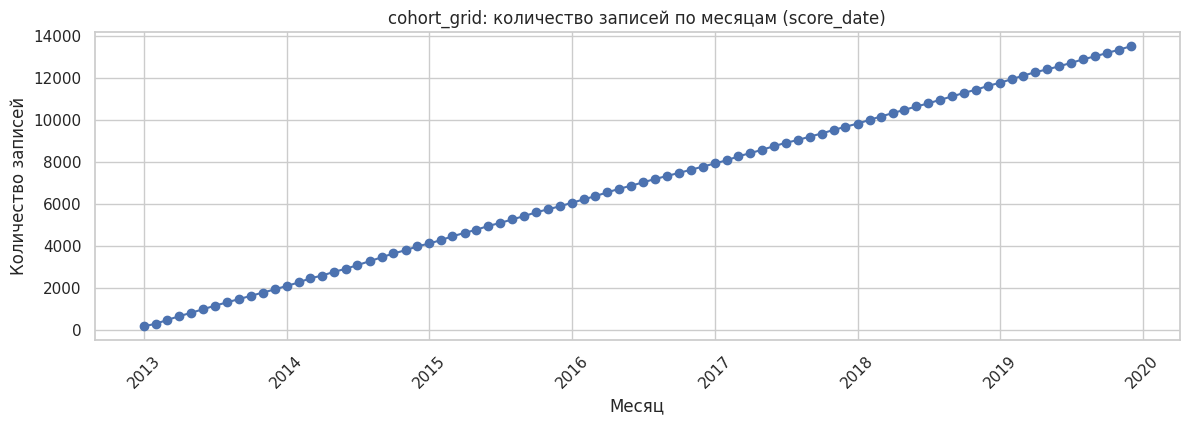

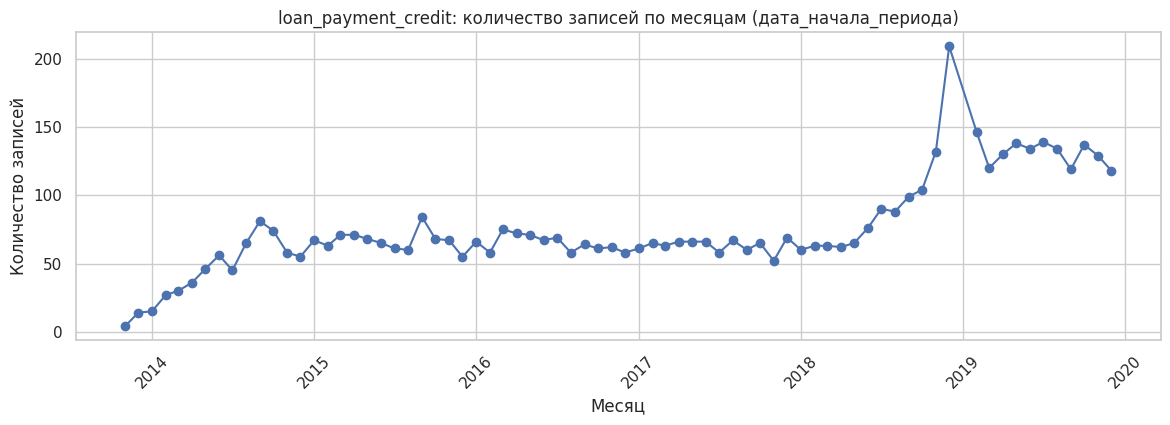

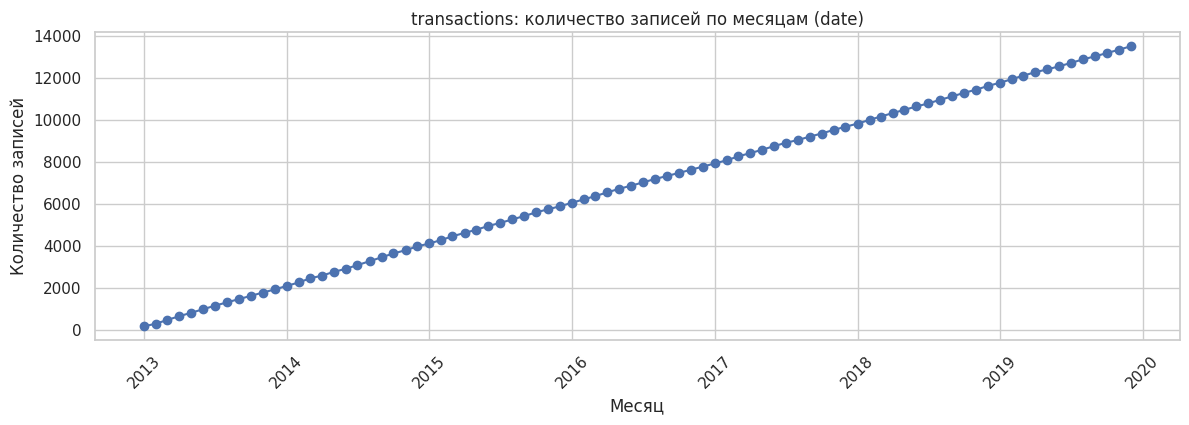

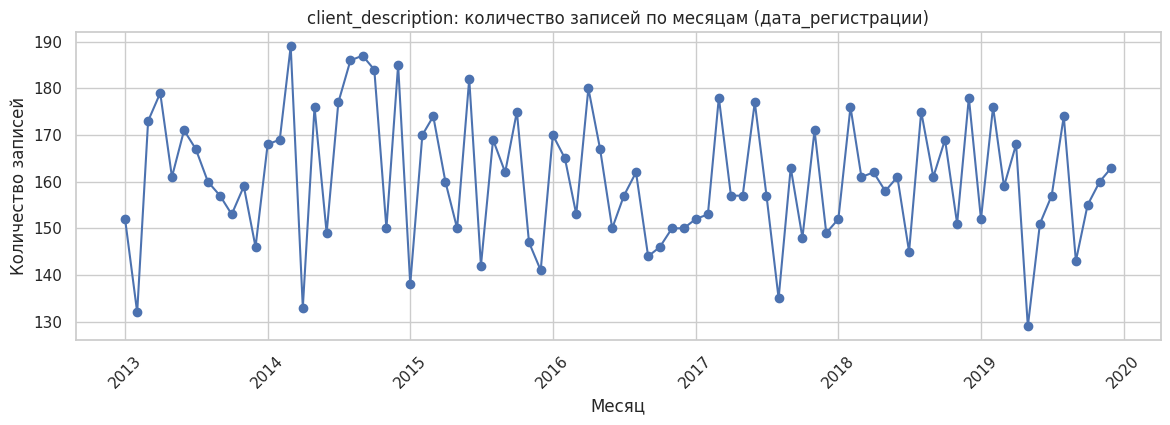

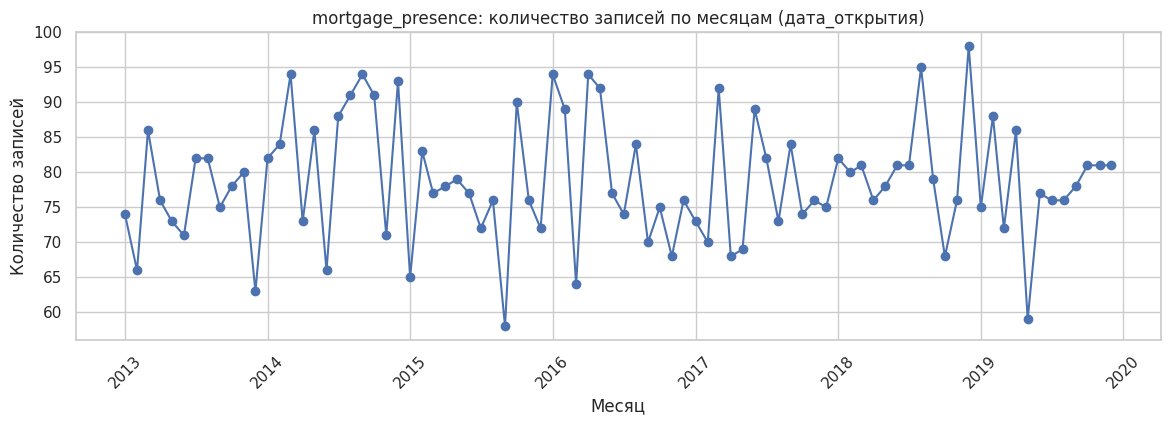

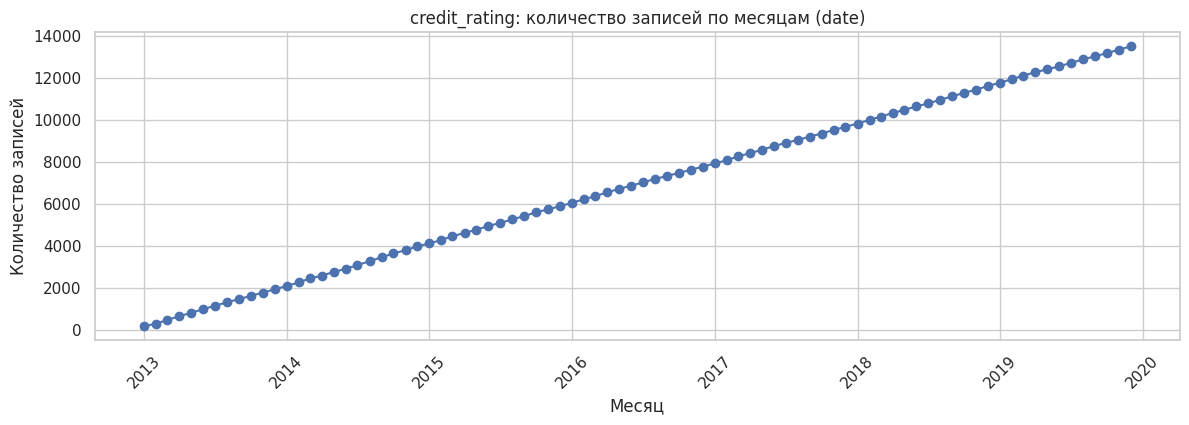

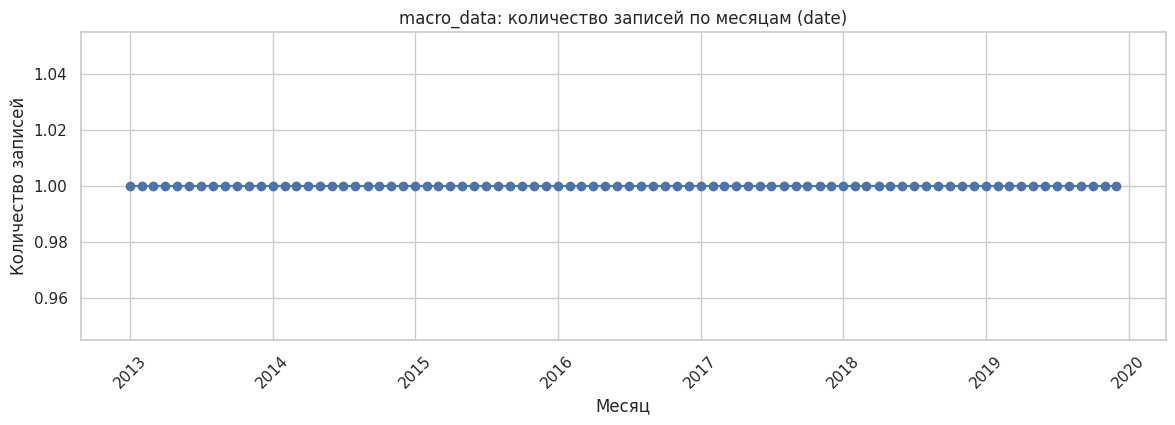

In [23]:
for name, df in df_mains.items():
    plot_date_coverage(name, df)

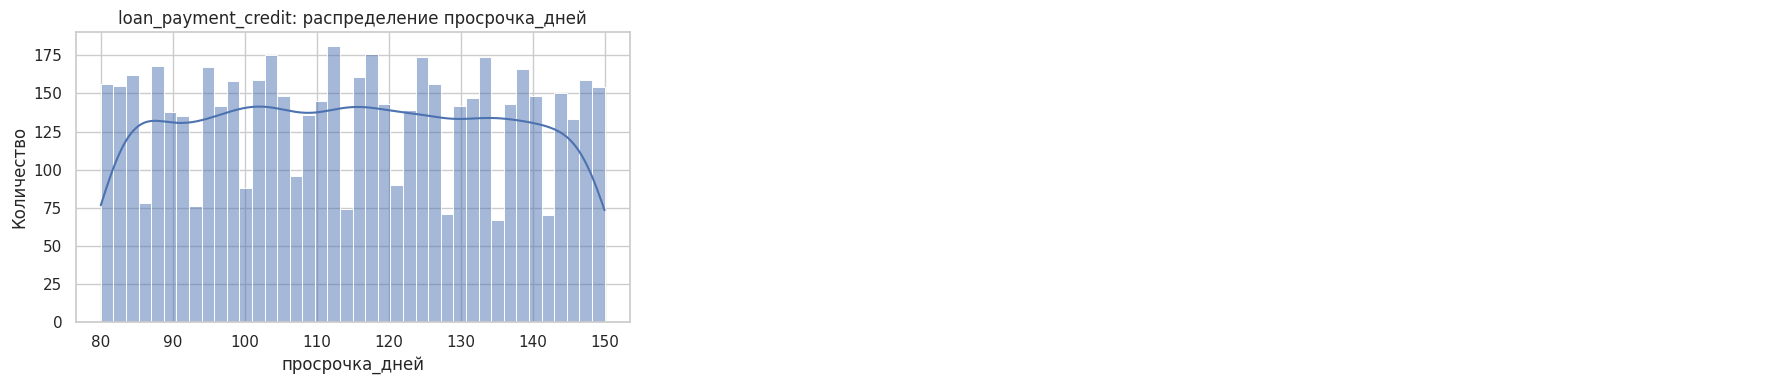

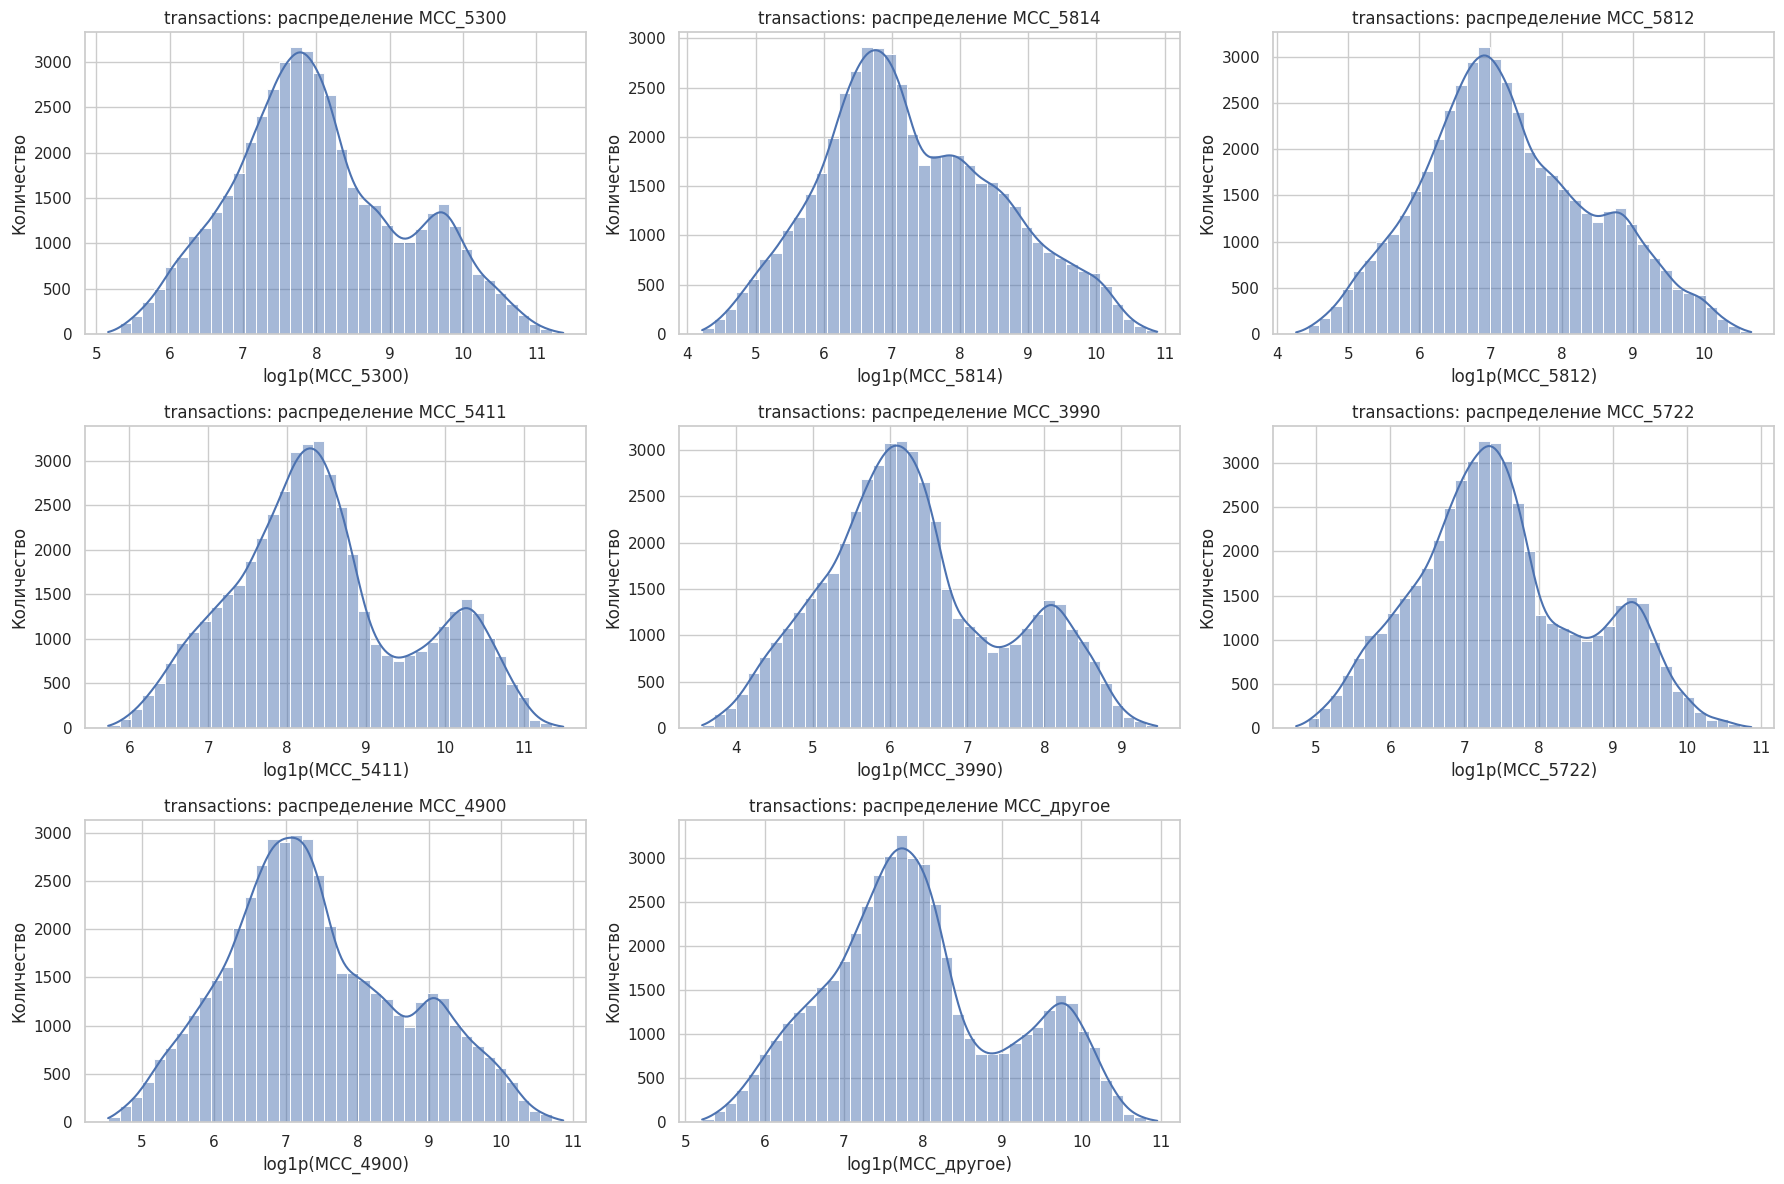

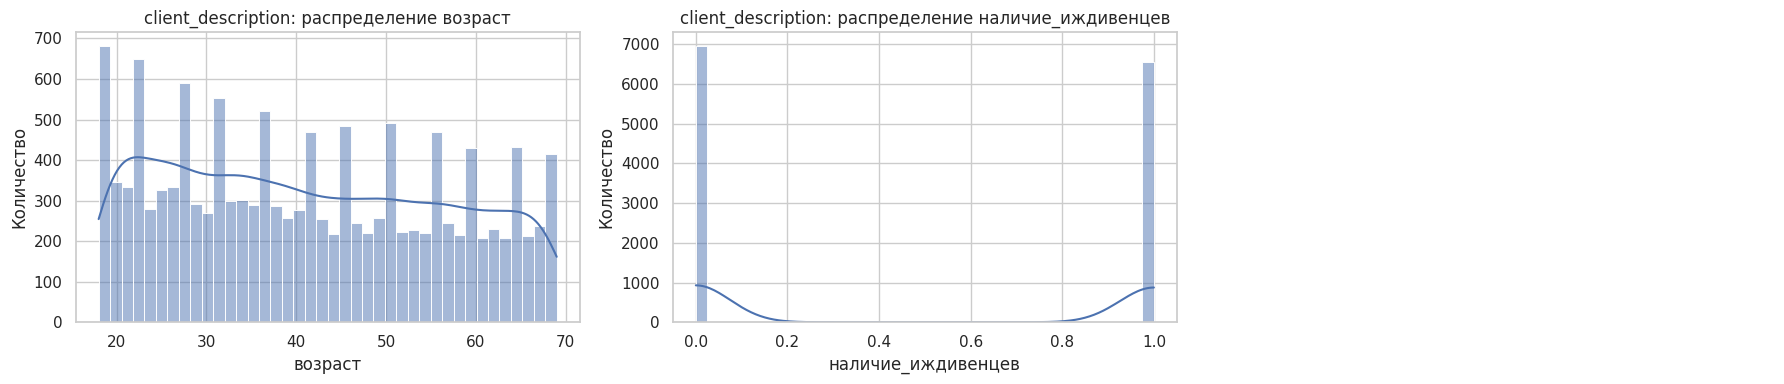

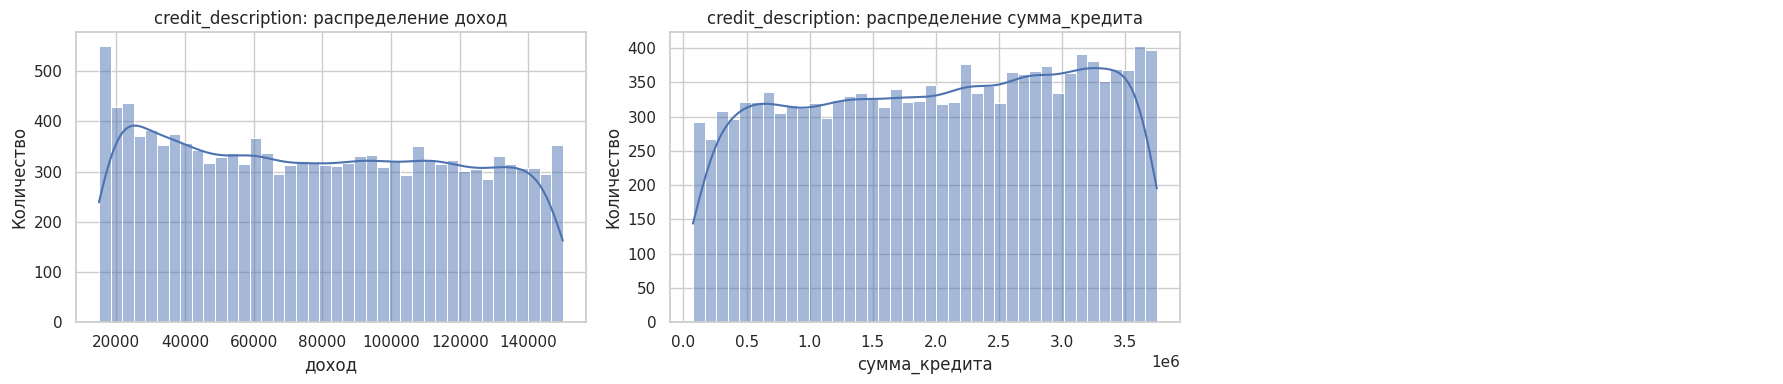

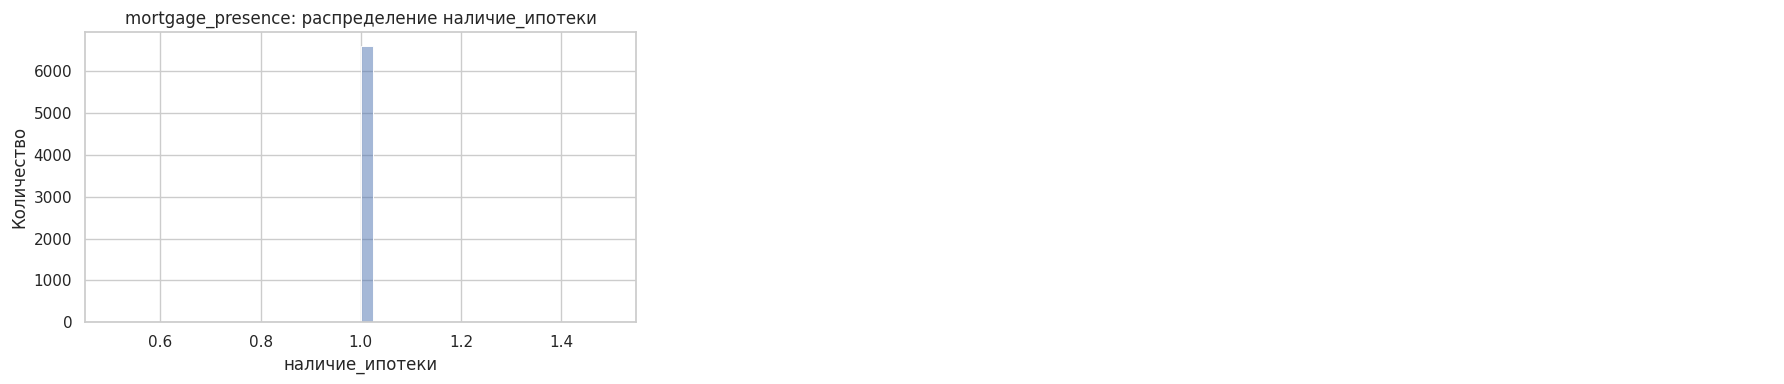

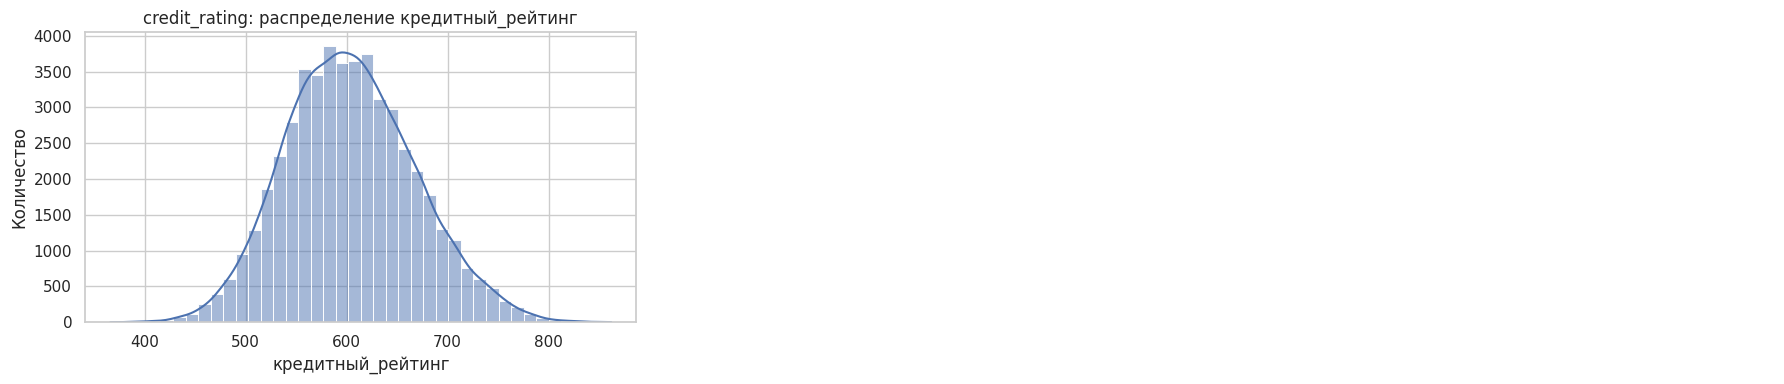

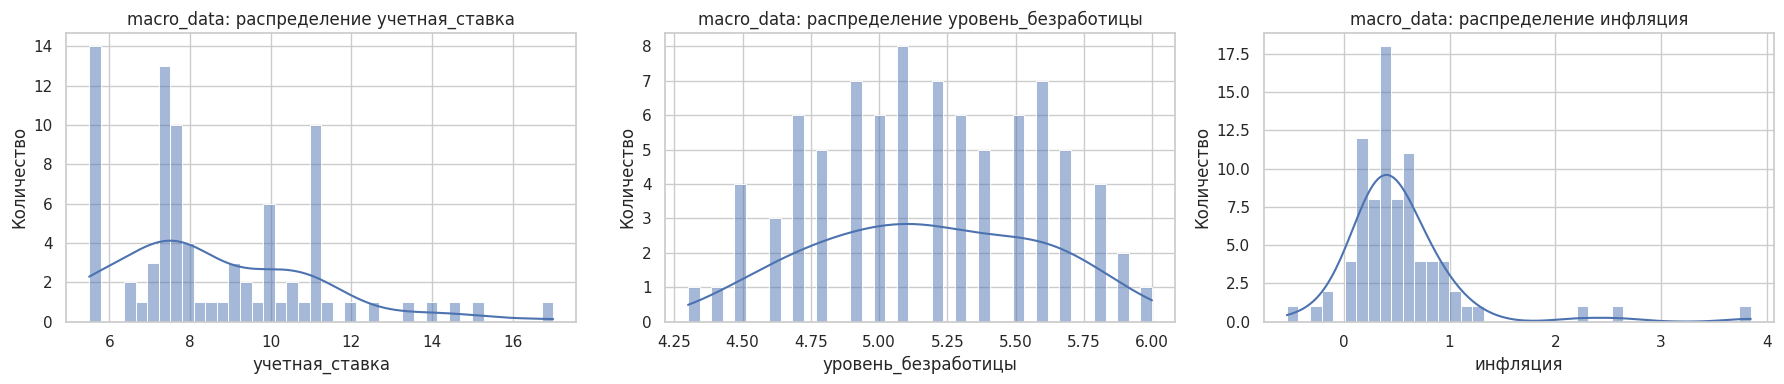

In [22]:
for name, df in df_mains.items():
    plot_numeric_distributions(name, df)

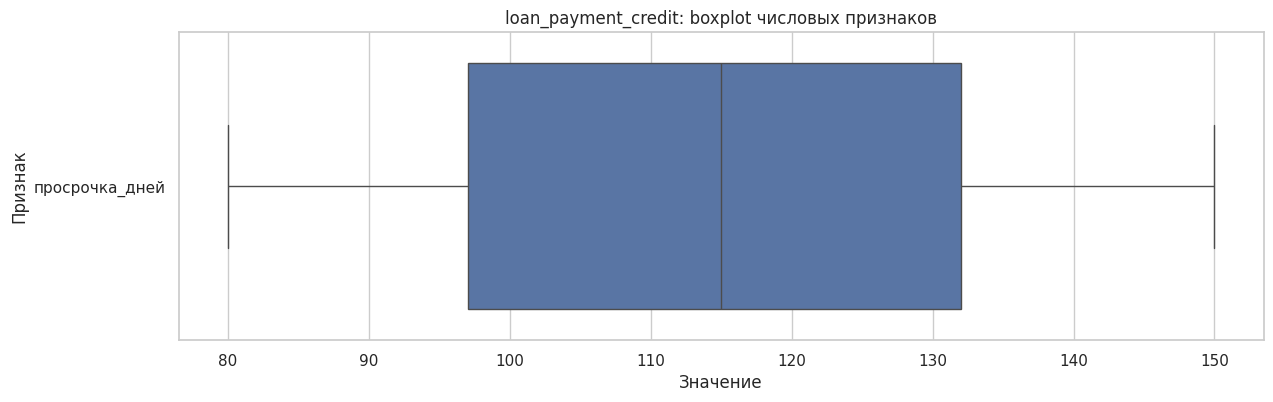

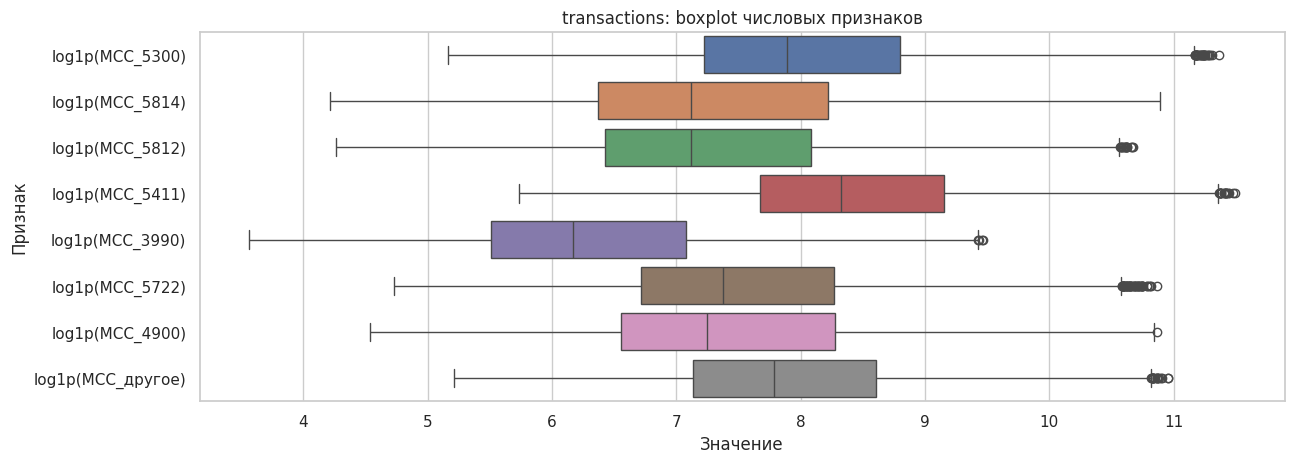

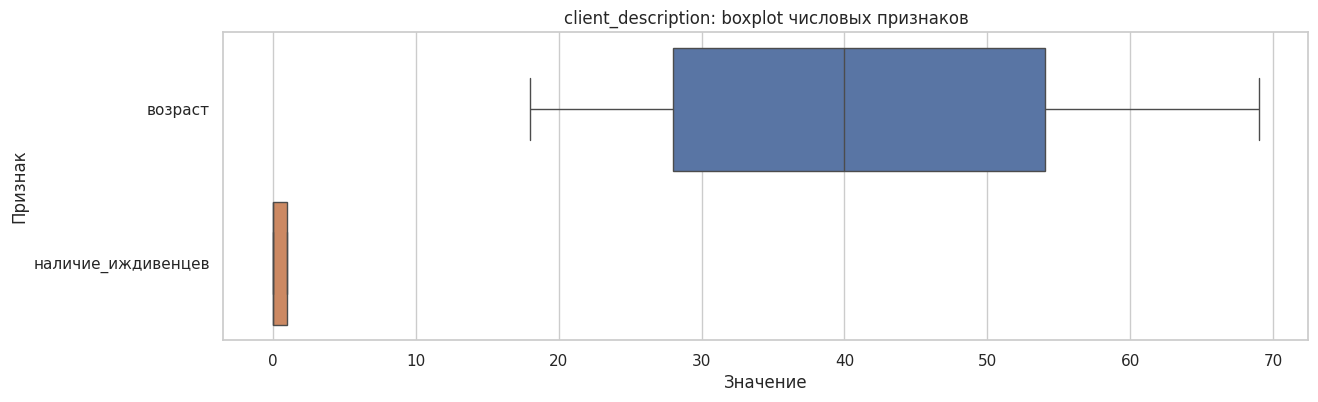

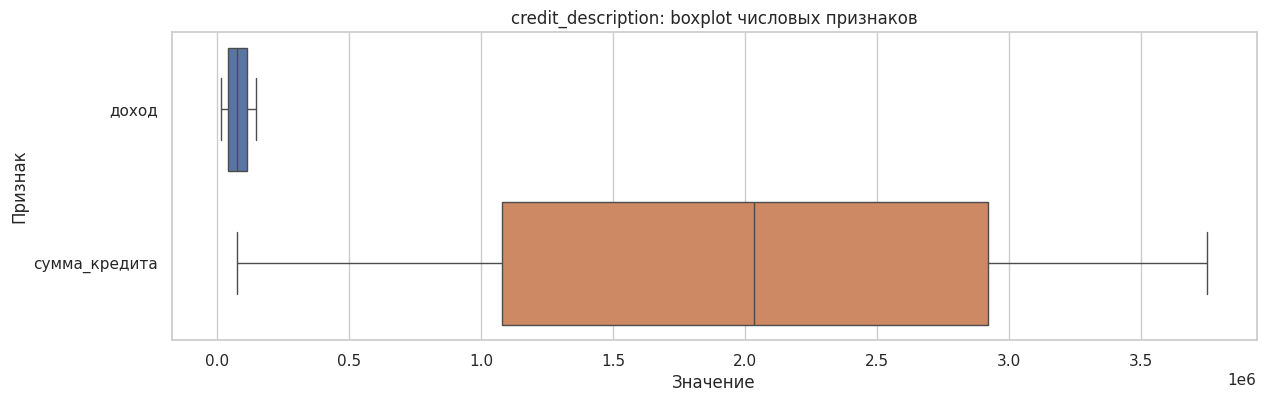

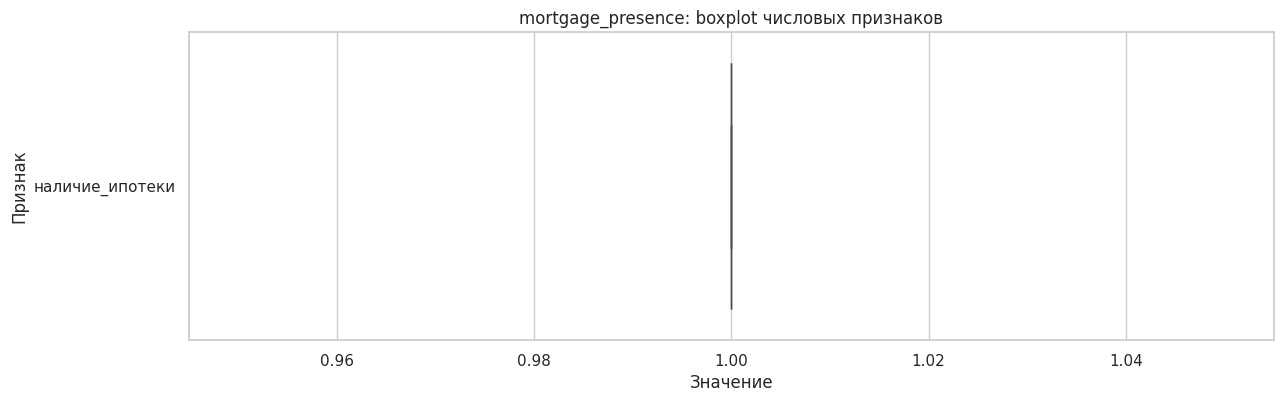

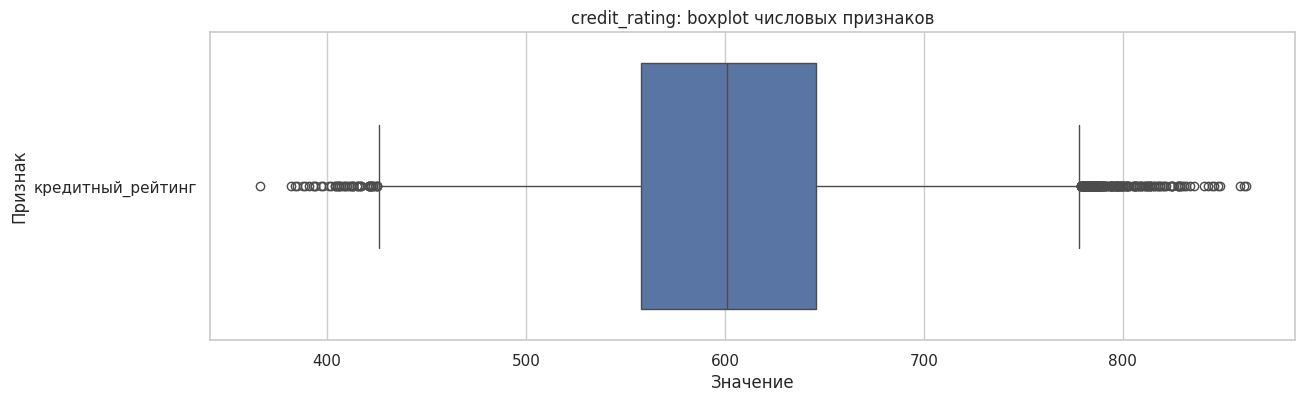

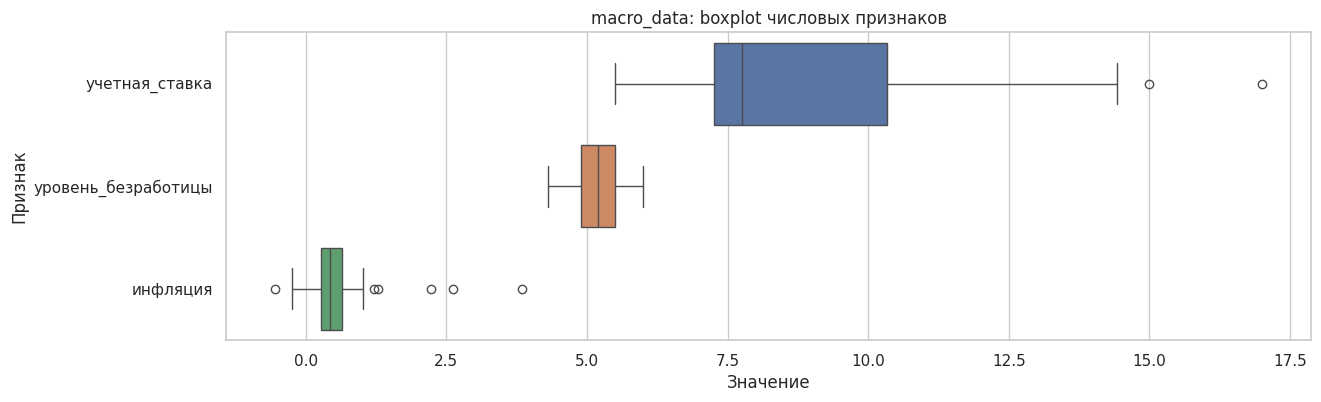

In [21]:
for name, df in df_mains.items():
    plot_numeric_boxplots(name, df)

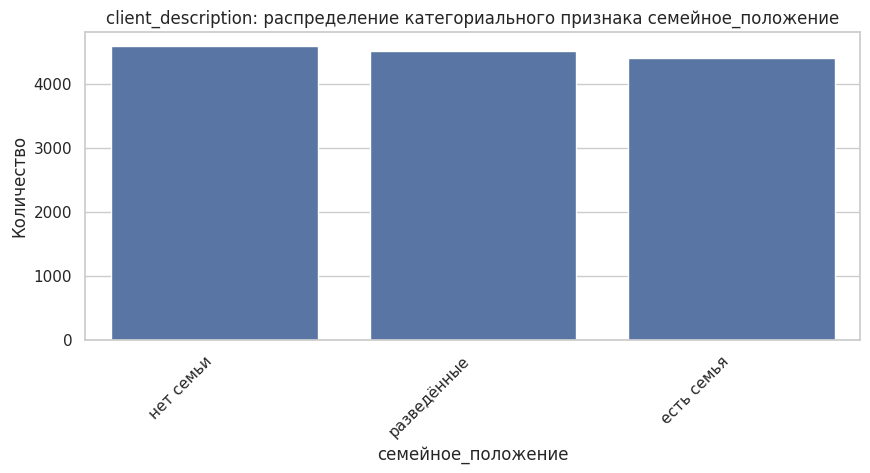

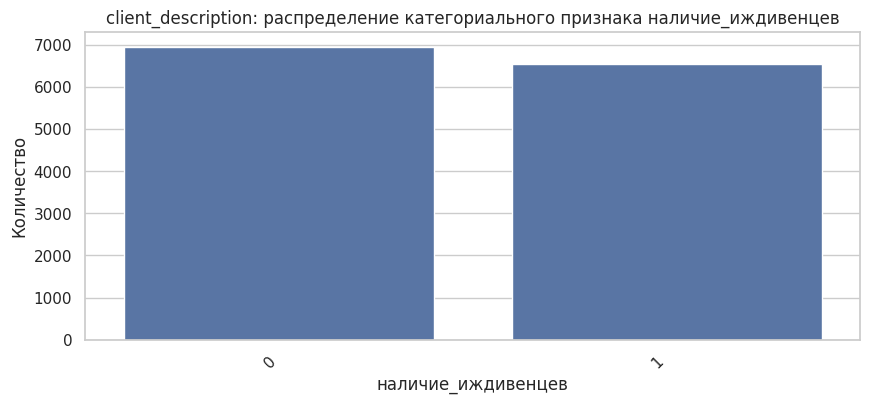

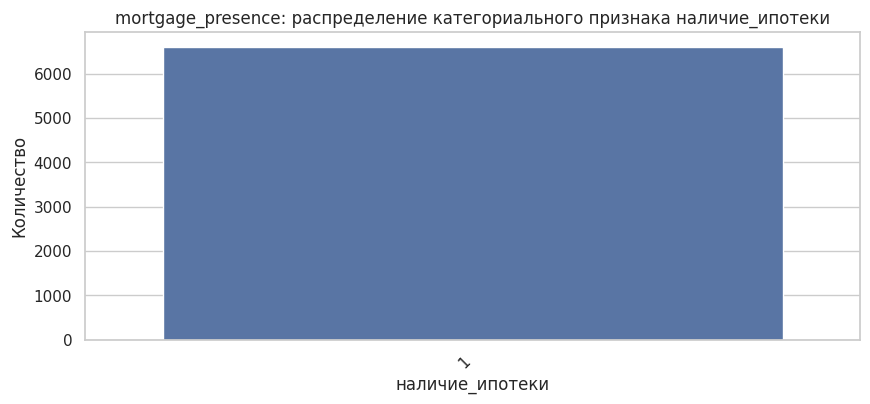

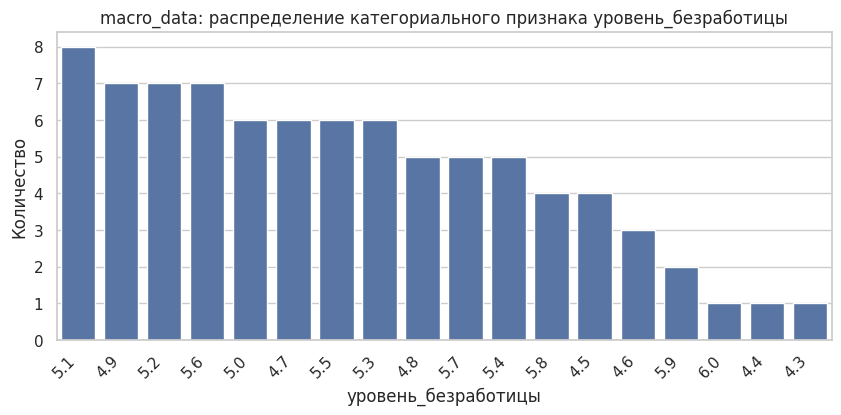

In [20]:
for name, df in df_mains.items():
    plot_categorical_distributions(name, df)

### Вывод по исследовательскому анализу данных

В ходе исследовательского анализа были изучены все исходные таблицы проекта. Для каждой таблицы были проверены размеры, типы данных, количество пропусков, явные дубликаты, число уникальных значений, диапазоны дат и распределения числовых признаков. Также были построены графики для анализа временного покрытия, количественных и категориальных признаков.

Во всех таблицах отсутствуют пропуски и явные дубликаты. Это означает, что на текущем этапе не требуется удалять строки или заполнять пропущенные значения. Однако календарные признаки после загрузки имеют тип `object`, поэтому перед объединением таблиц их необходимо привести к типу `datetime`.

Основная таблица `cohort_grid` содержит сетку наблюдений «клиент — дата скоринга». Она включает 577 494 строки и 13 500 уникальных клиентов. Даты скоринга покрывают период с января 2013 года по декабрь 2019 года. Таблицы `transactions` и `credit_rating` имеют такое же количество строк и клиентов, что говорит о согласованности этих источников с основной сеткой наблюдений.

В таблице транзакций все MCC-признаки являются числовыми. Их распределения имеют выраженную правостороннюю асимметрию: медианные значения заметно ниже максимальных. Это ожидаемо для финансовых расходов клиентов, так как отдельные клиенты могут совершать крупные траты в отдельных категориях. Такие значения не следует автоматически считать ошибками данных, но при построении модели стоит учитывать возможное влияние выбросов и создать агрегированные признаки по тратам.

Таблицы `client_description` и `credit_description` содержат по одной записи на каждого клиента. В них не выявлено дубликатов по `ID`. Возраст клиентов находится в реалистичном диапазоне от 18 до 69 лет. Признак `семейное_положение` содержит три категории, а `наличие_иждивенцев` является бинарным признаком.

Таблица `mortgage_presence` содержит только клиентов с ипотекой: признак `наличие_ипотеки` во всех строках равен 1. Поэтому отсутствие клиента в этой таблице при объединении нужно будет интерпретировать как отсутствие ипотеки. Также необходимо учитывать дату открытия ипотеки, чтобы не присвоить клиенту ипотеку раньше фактической даты её появления.

Таблица `loan_payment_credit` содержит 5 500 записей о клиентах с просрочками. Значения длительности просрочки лежат в диапазоне от 80 до 150 дней. Эта таблица является событийной и будет использоваться для формирования целевой переменной. Её нельзя напрямую присоединять как обычный признак без учёта временной логики, так как это может привести к утечке информации из будущего.

Таблица `macro_data` содержит помесячные макроэкономические показатели за тот же период, что и основная временная сетка. Её можно будет присоединить к итоговой таблице по месяцу скоринга.

В целом данные выглядят согласованными и пригодными для дальнейшей работы. Основные особенности, которые нужно учесть на следующих этапах: приведение дат к типу `datetime`, аккуратное объединение таблиц по временной логике, корректное формирование целевой переменной в горизонте 12 месяцев и недопущение утечки будущей информации в признаки.

## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

In [25]:
# Приводим даты к datetime
cohort_grid[SCORE_DATE_COL] = pd.to_datetime(
    cohort_grid[SCORE_DATE_COL],
    errors="coerce"
)

loan_payment_credit[DEFAULT_START_COL] = pd.to_datetime(
    loan_payment_credit[DEFAULT_START_COL],
    errors="coerce"
)

# Проверим, что даты распарсились корректно
print("Пропуски в score_date после преобразования:")
print(cohort_grid[SCORE_DATE_COL].isna().sum())

print("\nПропуски в дате начала периода просрочки после преобразования:")
print(loan_payment_credit[DEFAULT_START_COL].isna().sum())

Пропуски в score_date после преобразования:
0

Пропуски в дате начала периода просрочки после преобразования:
0


In [28]:
# Отбираем только дефолтные эпизоды: просрочка 90+ дней
default_events = loan_payment_credit[
    loan_payment_credit[DEFAULT_DAYS_COL] >= DEFAULT_DAYS_THRESHOLD
].copy()

# Если у клиента несколько дефолтных эпизодов, берём первый по времени
first_default_events = (
    default_events
    .sort_values([ID_COL, DEFAULT_START_COL])
    .groupby(ID_COL, as_index=False)
    .first()
    .rename(
        columns={
            DEFAULT_START_COL: "first_default_90plus_date",
            DEFAULT_DAYS_COL: "first_default_90plus_days",
        }
    )
)

print(f"Всего записей в таблице просрочек: {len(loan_payment_credit)}")
print(f"Эпизодов с просрочкой 90+ дней: {len(default_events)}")
print(f"Клиентов с хотя бы одним эпизодом 90+ дней: {first_default_events[ID_COL].nunique()}")

display(first_default_events.head())

Всего записей в таблице просрочек: 5500
Эпизодов с просрочкой 90+ дней: 4712
Клиентов с хотя бы одним эпизодом 90+ дней: 4712


,ID,first_default_90plus_date,first_default_90plus_days
0,IDF54896351,2014-10-01,93
1,IDF54896494,2019-07-01,137
2,IDF54896677,2017-09-01,90
3,IDF54896685,2017-11-01,136
4,IDF54896744,2019-02-01,97


In [29]:
# Базовая таблица наблюдений: каждая строка — клиент на дату скоринга
df_target_base = cohort_grid.merge(
    first_default_events[
        [ID_COL, "first_default_90plus_date", "first_default_90plus_days"]
    ],
    on=ID_COL,
    how="left"
)

# Конец горизонта прогнозирования: [score_date, score_date + 365 дней)
df_target_base["forecast_end_date"] = (
    df_target_base[SCORE_DATE_COL] + pd.Timedelta(days=HORIZON_DAYS)
)

# Сколько дней осталось до первого дефолта 90+
df_target_base["days_to_first_default"] = (
    df_target_base["first_default_90plus_date"] - df_target_base[SCORE_DATE_COL]
).dt.days

# Таргет равен 1, если первый дефолт 90+ попадает в горизонт [score_date, score_date + 365 дней)
df_target_base[TARGET] = (
    df_target_base["first_default_90plus_date"].notna()
    & (df_target_base["first_default_90plus_date"] >= df_target_base[SCORE_DATE_COL])
    & (df_target_base["first_default_90plus_date"] < df_target_base["forecast_end_date"])
).astype(int)

display(df_target_base.head())

,ID,score_date,first_default_90plus_date,first_default_90plus_days,forecast_end_date,days_to_first_default,target
0,IDF55109846,2013-05-01,2014-12-01,120.000,2014-05-01,579.000,0
1,IDF55109846,2013-06-01,2014-12-01,120.000,2014-06-01,548.000,0
2,IDF55109846,2013-07-01,2014-12-01,120.000,2014-07-01,518.000,0
3,IDF55109846,2013-08-01,2014-12-01,120.000,2014-08-01,487.000,0
4,IDF55109846,2013-09-01,2014-12-01,120.000,2014-09-01,456.000,0


In [30]:
# Строки, где первый дефолт уже случился к моменту скоринга
past_default_mask = (
    df_target_base["first_default_90plus_date"].notna()
    & (df_target_base["first_default_90plus_date"] < df_target_base[SCORE_DATE_COL])
)

print(f"Размер до удаления строк с уже произошедшим дефолтом: {df_target_base.shape}")
print(f"Строк к удалению: {past_default_mask.sum()}")

# Удаляем такие строки
df_observations = df_target_base.loc[~past_default_mask].copy()

print(f"Размер после удаления строк с уже произошедшим дефолтом: {df_observations.shape}")
print(f"Удалено строк: {df_target_base.shape[0] - df_observations.shape[0]}")

Размер до удаления строк с уже произошедшим дефолтом: (577494, 7)
Строк к удалению: 139115
Размер после удаления строк с уже произошедшим дефолтом: (438379, 7)
Удалено строк: 139115


In [ ]:
# Проверка: нет ли дубликатов по паре ID + score_date
duplicated_pairs = df_observations.duplicated([ID_COL, SCORE_DATE_COL]).sum()
print(f"Дубликатов по паре ID + score_date: {duplicated_pairs}")

# Проверка: после фильтрации не должно остаться строк, где дефолт уже был в прошлом
past_defaults_left = (
    df_observations["first_default_90plus_date"].notna()
    & (df_observations["first_default_90plus_date"] < df_observations[SCORE_DATE_COL])
).sum()

print(f"Строк с дефолтом в прошлом после фильтрации: {past_defaults_left}")

# Проверка значений таргета
print("\nРаспределение целевой переменной:")
target_distribution = (
    df_observations[TARGET]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

target_distribution["percent"] = (
    target_distribution["count"] / len(df_observations) * 100
).round(2)

display(target_distribution)

# Контрольные assert
assert duplicated_pairs == 0
assert past_defaults_left == 0
assert df_observations[TARGET].isin([0, 1]).all()

Дубликатов по паре ID + score_date: 0
Строк с дефолтом в прошлом после фильтрации: 0

Распределение целевой переменной:


,count,percent
target,,
0,389015,88.740
1,49364,11.260


,score_date,observations,target_1_count,target_1_share
0,2013-01-01,152,10,0.066
1,2013-02-01,284,24,0.085
2,2013-03-01,457,48,0.105
3,2013-04-01,636,71,0.112
4,2013-05-01,797,98,0.123


,score_date,observations,target_1_count,target_1_share
79,2019-08-01,8714,333,0.038
80,2019-09-01,8737,266,0.030
81,2019-10-01,8790,225,0.026
82,2019-11-01,8839,160,0.018
83,2019-12-01,8888,100,0.011


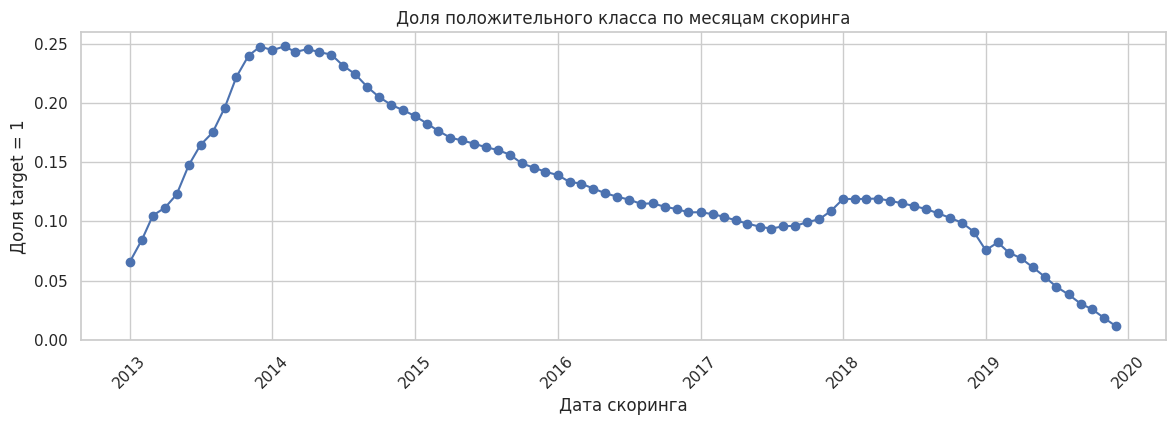

In [33]:
target_by_month = (
    df_observations
    .groupby(SCORE_DATE_COL)[TARGET]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "observations",
            "sum": "target_1_count",
            "mean": "target_1_share",
        }
    )
    .reset_index()
)

display(target_by_month.head())
display(target_by_month.tail())

plt.figure(figsize=(14, 4))
plt.plot(
    target_by_month[SCORE_DATE_COL],
    target_by_month["target_1_share"],
    marker="o"
)
plt.title("Доля положительного класса по месяцам скоринга")
plt.xlabel("Дата скоринга")
plt.ylabel("Доля target = 1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Промежуточный вывод по формированию целевой переменной

На этом этапе была сформирована бинарная целевая переменная `target` для каждой строки из таблицы `cohort_grid`, то есть для каждой пары «клиент — дата скоринга». Перед расчётом таргета даты в таблицах `cohort_grid` и `loan_payment_credit` были приведены к типу `datetime`. Ошибок преобразования дат не обнаружено: пропуски после преобразования отсутствуют.

В таблице просрочек содержится 5 500 записей. Из них 4 712 эпизодов соответствуют условию дефолта, то есть имеют длительность просрочки 90 дней и более. Для каждого клиента был выбран первый по времени эпизод просрочки 90+ дней, так как именно он используется для корректного определения будущего дефолта относительно даты скоринга.

Для каждой строки из `cohort_grid` был рассчитан горизонт прогнозирования: интервал от `score_date` до `score_date + 365 дней`. Целевая переменная получила значение `1`, если первый дефолт клиента попадал в этот интервал, и `0` — если дефолт не попадал в горизонт прогнозирования или у клиента не было дефолта 90+ дней.

После расчёта таргета были удалены строки, в которых дефолт уже произошёл до даты скоринга. Это необходимо, потому что такие наблюдения не соответствуют задаче прогнозирования будущего риска: на момент скоринга дефолт уже известен. До удаления таблица содержала 577 494 строки, после удаления осталось 438 379 строк. Было удалено 139 115 строк с уже произошедшим дефолтом.

Дополнительные проверки показали, что в итоговой таблице наблюдений нет дубликатов по паре `ID` и `score_date`, а также не осталось строк, где дата первого дефолта находится в прошлом относительно даты скоринга. Это подтверждает корректность временной фильтрации.

Распределение целевой переменной показывает дисбаланс классов: положительный класс `target = 1` составляет 49 364 наблюдения, или 11.26% выборки, отрицательный класс `target = 0` — 389 015 наблюдений, или 88.74%. Следовательно, задача является несбалансированной бинарной классификацией. На этапе моделирования потребуется учитывать дисбаланс классов с помощью специальных методов балансировки или весов классов.

Также видно, что доля положительного класса меняется во времени: в начале периода она постепенно растёт, а к концу 2019 года заметно снижается. Это ожидаемо, так как для последних месяцев наблюдений горизонт будущего дефолта ограничен доступными данными. При дальнейшем разбиении выборки и кросс-валидации необходимо учитывать временную структуру данных.

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.

